## Slides RL 2
- Ok in part 2 I found what I think should be a pretty productive set of examples
- Now I can start printing stuff for slides
- I believe there's a scaling issue in here impacting the reported probs, I don't think it's a huge problem, on a tight deadeline for pres tomorrow, going to keep moving and see if we can ignore for now (seems like things even out?), but should come back at some point. Part 2 has more details. 

In [1]:
BLUE="#2ca3dd"
YELLOW="#ffd35a"
RED='#ec2027'
CHILL_BROWN="#948979"

In [2]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
from matplotlib.path import Path
from matplotlib.markers import MarkerStyle
from matplotlib.patches import FancyBboxPatch, Circle
# from pathlib import Path
import os

import matplotlib.colors as mcolors
cmap = mcolors.LinearSegmentedColormap.from_list("blue_gold", [BLUE, YELLOW], N=256)

In [3]:
def style_ax(ax, color=CHILL_BROWN):
    ax.spines[:].set_color(color)
    ax.tick_params(colors=color, which='both')
    ax.xaxis.label.set_color(color)
    ax.yaxis.label.set_color(color)
    ax.title.set_color(color)


def arrow_path(direction=1, shaft_w=0.28, head_w=0.9, head_len=0.9, total_len=2.0):
    hl = head_len; sw = shaft_w/2; hw = head_w/2; L = total_len/2
    verts = np.array([
        (-L,  sw), (L-hl,  sw), (L-hl,  hw), (L, 0),
        (L-hl, -hw), (L-hl, -sw), (-L, -sw), (-L, sw),
    ]) * direction   # direction=-1 mirrors -> left arrow
    codes = [Path.MOVETO] + [Path.LINETO]*6 + [Path.CLOSEPOLY]
    return Path(verts, codes)

In [4]:
HACKIN_DIR = '/Volumes/hot_1/Stephencwelch Dropbox/welch_labs/rl_1/hackin'
# HACKIN_DIR = '/Users/stephen/Library/CloudStorage/Dropbox-Stephencwelch/welch_labs/rl_1/hackin'

In [5]:
VEL_SCALE = 10   # divide all velocities by 10 -> feature scales comparable, ~isotropic parameter space

In [6]:
CART_W, CART_H, POLE_LEN, WHEEL_R = 0.5, 0.26, 1.0, 0.07

def draw_cartpole(ax, cart_x, pole_theta, action=None):
    ax.set_xlim(-2.4, 2.4); ax.set_ylim(-0.55, 1.75)
    ax.set_aspect('equal'); ax.axis('off')
    ax.plot([-2.4, 2.4], [0, 0], color=CHILL_BROWN, lw=1.5, zorder=1)   # track
    cart_y = WHEEL_R*2
    for dx in (-CART_W*0.3, CART_W*0.3):
        ax.add_patch(Circle((cart_x+dx, WHEEL_R), WHEEL_R, color=CHILL_BROWN, zorder=3))
    ax.add_patch(FancyBboxPatch((cart_x-CART_W/2, cart_y), CART_W, CART_H,
                 boxstyle="round,pad=0.02,rounding_size=0.05",
                 fc='#3a3a3a', ec=CHILL_BROWN, lw=1.5, zorder=4))
    px, py = cart_x, cart_y + CART_H
    ax.plot([px, px + POLE_LEN*np.sin(pole_theta)],
            [py, py + POLE_LEN*np.cos(pole_theta)],
            color='w', lw=6, solid_capstyle='round', zorder=5)
    ax.add_patch(Circle((px, py), 0.045, color=CHILL_BROWN, zorder=6))
    if action is not None:   # action arrow under the cart, your color convention
        ax.scatter([cart_x], [-0.32],
                   marker=(RIGHT_ARROW if action==1 else LEFT_ARROW), s=420,
                   color=(YELLOW if action==1 else BLUE), linewidths=0, zorder=5)

In [7]:
RIGHT_ARROW = MarkerStyle(arrow_path(+1))
LEFT_ARROW  = MarkerStyle(arrow_path(-1))

ANG_LIM = (-13, 13) #Ok I want this to be in degrees!
VEL_LIM = (-17, 17)   # angvel data is pre-divided by VEL_SCALE=10

## 0. Some setup and baselines

In [8]:
class Pi(nn.Module):
    """Two-parameter policy: logit = theta1 * pole_angle + theta2 * pole_ang_velocity.

    P(right) = sigmoid(logit). Returns [P(left), P(right)] with shape (2,) or (T, 2),
    so the REINFORCE loop below is unchanged from the neural net version.
    """
    def __init__(self):
        super().__init__()
        self.theta = nn.Parameter(torch.zeros(2))  # [theta1, theta2] -> uniform random policy at init

    def forward(self, x):
        feats = x[..., 2:4]                # state indices 2, 3: pole angle, pole angular velocity
        logit = feats @ self.theta         # scalar or (T,)
        p_right = torch.sigmoid(logit)
        return torch.stack([1.0 - p_right, p_right], dim=-1)

In [9]:
# This might be cleaner scaling wise, but I have a good amount of tech debt doing it the other way
# let me see if I can get the job done w/o this. 

# class Pi(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.theta = nn.Parameter(torch.zeros(2))

#     def forward(self, x):
#         feats = x[..., 2:4] * (180 / np.pi)   # degree-scale features
#         logit = feats @ self.theta
#         p_right = torch.sigmoid(logit)
#         return torch.stack([1.0 - p_right, p_right], dim=-1)

In [10]:
def scale_state(s):
    s = s.astype(np.float32).copy()
    s[1] /= VEL_SCALE; s[3] /= VEL_SCALE   # same /10 velocity scaling as the demo data
    return s

def run_rollout(seed, deterministic=False):
    # --- rollout: collect one episode ---
    states, actions, rewards = [], [], []
    state, _ = env.reset(seed=seed)
    state = scale_state(state)
    for t in range(500):                                # CartPole-v1 max timestep is 500
        with torch.no_grad():                           # no graph needed here; we recompute below
            probs = pi(torch.from_numpy(state))

        if deterministic:
            action=probs.argmax().item() #Armax instead of sample!
        else:
            action = np.random.choice(out_dim, p=probs.numpy())

        states.append(state)                            # note: stored states are velocity-scaled
        actions.append(action)
        state, reward, terminated, truncated, _ = env.step(action)
        state = scale_state(state)
        rewards.append(reward)
        if terminated or truncated:
            break

    return states, actions, rewards

In [11]:
env = gym.make('CartPole-v1')
out_dim = env.action_space.n              
gamma=1.0

torch.manual_seed(52)
np.random.seed(52)
pi = Pi()

pi.theta=nn.Parameter(torch.tensor([0.1, 0.2]))

# optimizer = optim.Adam(pi.parameters(), lr=0.05)  # 2 params only -> larger lr than the NN version
optimizer = optim.SGD(pi.parameters(), lr=0.007)  # plain SGD: steps follow raw gradient direction (better for viz)
# optimizer = optim.SGD(pi.parameters(), lr=0.00005)  # plain SGD: steps follow raw gradient direction (better for viz)

In [12]:
total_rewards = []

for epi in tqdm(range(500)):

    states, actions, rewards = run_rollout(seed=epi)
    # --- discounted returns-to-go: G_t = r_t + gamma * G_{t+1}, computed backwards ---
    T = len(rewards)
    rets = np.empty(T, dtype=np.float32)
    future_ret = 0.0
    for t in reversed(range(T)):
        future_ret = rewards[t] + gamma * future_ret
        rets[t] = future_ret
    rets = torch.tensor(rets)
    
    # rets = (rets - rets.mean()) / (rets.std() + 1e-8)   # baseline + variance normalization

    # --- REINFORCE update: one batched forward over the whole episode ---
    state_batch = torch.tensor(np.array(states, dtype=np.float32))   # (T, 4)
    action_batch = torch.tensor(actions)                              # (T,)
    prob_batch = pi(state_batch)                                      # (T, 2)
    act_probs = prob_batch[torch.arange(T), action_batch]             # prob of each action actually taken
    
    loss = -(torch.log(act_probs) * rets).sum()
    # loss = -(act_probs * rets).sum()
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_rewards.append(sum(rewards))

100%|████████████████████████████████| 500/500 [00:02<00:00, 201.31it/s]


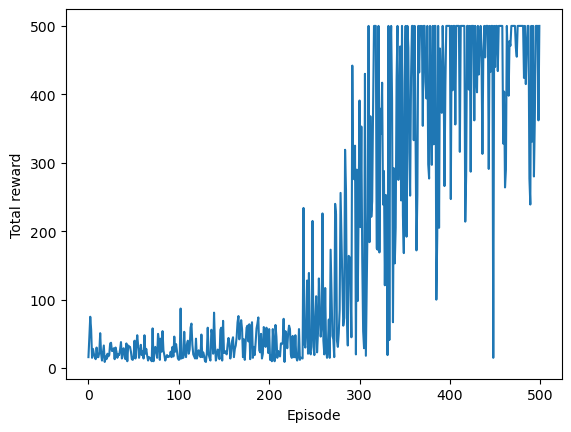

In [13]:
plt.plot(total_rewards)
plt.xlabel('Episode')
plt.ylabel('Total reward');

### 1 Stochastic Sweep 

In [14]:
# num_samples=32
# num_steps=32

# theta1_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps)
# theta2_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps) 

# all_rewards=[]

# for t1 in tqdm(theta1_vals_viz):
#     all_rewards.append([])
#     for t2 in theta2_vals_viz:
#         all_rewards[-1].append([])
#         for i in range(num_samples):
#             pi = Pi()
#             pi.theta=nn.Parameter(torch.tensor([t1.item(), t2.item()]))
#             states, actions, rewards = run_rollout(seed=i, deterministic=False) 
#             all_rewards[-1][-1].append(np.sum(rewards).item())
# all_rewards=np.array(all_rewards)

In [15]:
# Load from disk
all_rewards = np.load(HACKIN_DIR+'/256_100_sto_2.npy')

In [16]:
avg_reward=np.mean(all_rewards, 2)
std_reward=np.std(all_rewards, 2)

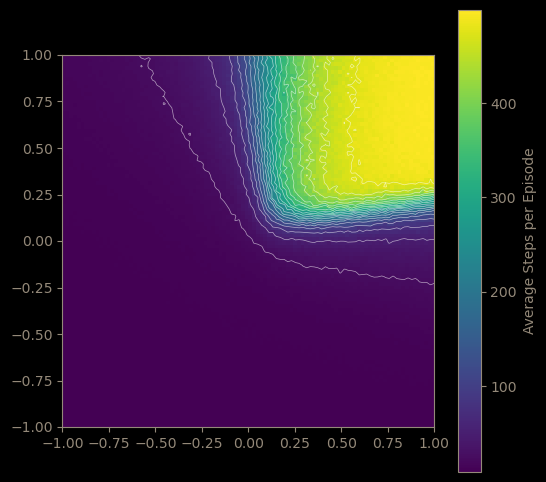

In [17]:
num_steps=all_rewards.shape[0]
theta1_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps)
theta2_vals_viz = np.linspace(-180/np.pi, 180/np.pi, num_steps) 

fig=plt.figure(0, (6,6), facecolor='k')
ax=fig.add_subplot(111)
extent=np.array([theta1_vals_viz[0], theta1_vals_viz[-1], theta2_vals_viz[0], theta2_vals_viz[-1]])
# im = ax.imshow(np.log(avg_reward.T), origin='lower', cmap='viridis',extent=np.radians(extent), aspect='equal') 
im = ax.imshow(avg_reward.T, origin='lower', cmap='viridis',extent=np.radians(extent), aspect='equal') 
T1, T2 = np.meshgrid(np.radians(theta1_vals_viz), np.radians(theta2_vals_viz))
cs = ax.contour(T1, T2, avg_reward.T, levels=20, colors='w', linewidths=0.5, alpha=0.6)
cb = fig.colorbar(im, ax=ax)
style_ax(ax)
cb.set_label('Average Steps per Episode', color=CHILL_BROWN)
cb.ax.yaxis.set_tick_params(color=CHILL_BROWN)
plt.setp(cb.ax.get_yticklabels(), color=CHILL_BROWN)
cb.outline.set_edgecolor(CHILL_BROWN)
plt.savefig(HACKIN_DIR+'/return_landscape_stochastic_3.png', dpi=240)

## 2. Render a collection of examples that I can show in a nice a grid

In [18]:
def draw_traj_panel(ax, ep):
    obs_e, act_e = ep['obs'], ep['act']
    ang, angvel = np.degrees(obs_e[:, 2]), np.degrees(obs_e[:, 3])
    A, V = np.meshgrid(np.linspace(*ANG_LIM, 160), np.linspace(*VEL_LIM, 160))
    P_right_grid = 1 / (1 + np.exp(-(t1 * A + t2 * V)))
    ax.imshow(P_right_grid, origin='lower', cmap=cmap, vmin=0, vmax=1,
              extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.4)
    ax.contour(A, V, P_right_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)
    ax.plot(ang, angvel, color='w', lw=1.0, alpha=0.25, zorder=3, solid_capstyle='round')
    m = act_e == 1
    ax.scatter(ang[m],  angvel[m],  marker=RIGHT_ARROW, s=180, color=YELLOW, alpha=0.85, linewidths=0, zorder=4)
    ax.scatter(ang[~m], angvel[~m], marker=LEFT_ARROW,  s=180, color=BLUE,   alpha=0.85, linewidths=0, zorder=4)
    made_it = len(act_e) == 500
    ax.scatter([ang[-1]], [angvel[-1]],
               marker=(RIGHT_ARROW if act_e[-1]==1 else LEFT_ARROW), s=260,
               facecolors='none', edgecolors=('w' if made_it else RED), linewidths=1.6, zorder=5)
    ax.text(0.02, 0.97, f'Steps = {len(act_e)}', transform=ax.transAxes,
            ha='left', va='top', color=CHILL_BROWN, fontsize=14)
    ax.set_xlim(*ANG_LIM); ax.set_ylim(*VEL_LIM)
    ax.set_xlabel('pole angle (degrees)'); ax.set_ylabel('pole angular velocity')
    ax.set_title('State Space'); style_ax(ax)

In [19]:
t1, t2 = -0.5, 0.00 #ok this actually feels pretty solid and explainable, lets go!!

pi = Pi()
pi.theta = nn.Parameter(torch.tensor([t1, t2]))     # set EXPLICITLY on pi itself
print('policy theta:', pi.theta.detach().numpy())

N_EPS = 1024
np.random.seed(0)
eps = []
for i in tqdm(range(N_EPS)):
    states, actions, rewards = run_rollout(seed=0, deterministic=False)  # seed=i -> same start dist as sweep
    eps.append({'obs': np.array(states), 'act': np.array(actions), 'R': float(np.sum(rewards))})
R = np.array([e['R'] for e in eps])
print(f'returns: mean {R.mean():.1f}  min {R.min():.0f}  max {R.max():.0f}')

policy theta: [-0.5  0. ]


100%|█████████████████████████████| 1024/1024 [00:00<00:00, 1626.31it/s]

returns: mean 21.0  min 8  max 78


In [22]:
# Probability of each rollout: product over timesteps of pi(a_t | s_t).
# Dynamics are deterministic + fixed start (seed=0), so this is the full rollout prob.
for ep in eps:
    state_batch  = torch.tensor(ep['obs'], dtype=torch.float32)   # (T, 4)
    action_batch = torch.tensor(ep['act'])                        # (T,)
    T = len(action_batch)

    with torch.no_grad():
        prob_batch = pi(state_batch)                              # (T, 2)
    act_probs = prob_batch[torch.arange(T), action_batch]         # prob of each action taken

    ep['log_prob'] = torch.log(act_probs).sum().item()            # log P(rollout)
    ep['prob']     = np.exp(ep['log_prob'])                       # P(rollout)

log_probs = np.array([e['log_prob'] for e in eps])
probs     = np.array([e['prob'] for e in eps])
print(f'log probs: mean {log_probs.mean():.1f}  min {log_probs.min():.1f}  max {log_probs.max():.1f}')
print(f'probs: min {probs.min():.2e}  max {probs.max():.2e}  sum {probs.sum():.2e}')

log probs: mean -14.5  min -54.1  max -5.4
probs: min 3.17e-24  max 4.69e-03  sum 2.33e-01


In [34]:
# For each rollout, compute:
#   prob:          P(rollout) = prod_t pi(a_t | s_t)
#   grad_log_prob: ∇θ log P(rollout) = Σ_t ∇θ log π(a_t|s_t)   (the REINFORCE direction)
#   grad_prob:     ∇θ P(rollout) = P(rollout) · ∇θ log P(rollout)
for ep in eps:
    state_batch  = torch.tensor(ep['obs'], dtype=torch.float32)   # (T, 4)
    action_batch = torch.tensor(ep['act'])                        # (T,)
    T = len(action_batch)

    prob_batch = pi(state_batch)                                  # (T, 2) — graph kept this time
    act_probs  = prob_batch[torch.arange(T), action_batch]
    log_prob   = torch.log(act_probs).sum()

    ep['log_prob'] = log_prob.item()
    ep['prob']     = np.exp(ep['log_prob'])
    ep['grad_log_prob'] = torch.autograd.grad(log_prob, pi.theta)[0].numpy()
    ep['grad_prob']     = ep['prob'] * ep['grad_log_prob']

grad_logs  = np.array([e['grad_log_prob'] for e in eps])   # (N_EPS, 2)
grad_probs = np.array([e['grad_prob'] for e in eps])
print('grad log prob: mean', grad_logs.mean(0), ' |max|', np.abs(grad_logs).max())
print('grad prob:     mean', grad_probs.mean(0), ' |max|', np.abs(grad_probs).max())

grad log prob: mean [-0.00020176 -0.00085914]  |max| 0.8428488
grad prob:     mean [-3.70938580e-05 -3.49312159e-05]  |max| 0.0020718487004362453


Text(0.5, 1.0, '9.211103387732331e-07')

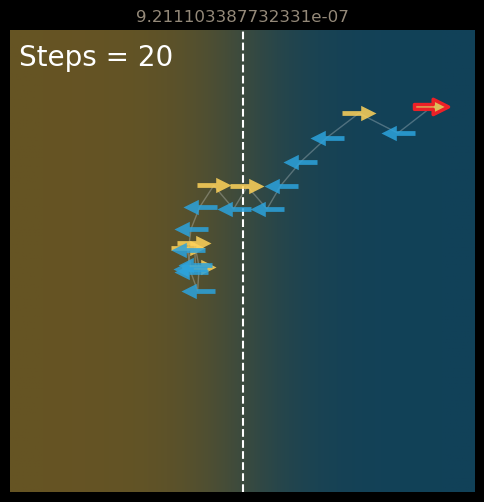

In [27]:
k=30

fig=plt.figure(0, (6, 6), facecolor='k')
ax=fig.add_subplot(111, facecolor='k')

ep=eps[k]
obs_e, act_e = ep['obs'], ep['act']
ang, angvel = np.degrees(obs_e[:, 2]), np.degrees(obs_e[:, 3])
A, V = np.meshgrid(np.linspace(*ANG_LIM, 160), np.linspace(*VEL_LIM, 160))
P_right_grid = 1 / (1 + np.exp(-(t1 * A + t2 * V)))
ax.imshow(P_right_grid, origin='lower', cmap=cmap, vmin=0, vmax=1,
          extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.4)
ax.contour(A, V, P_right_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)
ax.plot(ang, angvel, color='w', lw=1.0, alpha=0.25, zorder=3, solid_capstyle='round')
m = act_e == 1
ax.scatter(ang[m],  angvel[m],  marker=RIGHT_ARROW, s=600, color=YELLOW, alpha=0.85, linewidths=0, zorder=4)
ax.scatter(ang[~m], angvel[~m], marker=LEFT_ARROW,  s=600, color=BLUE,   alpha=0.85, linewidths=0, zorder=4)
made_it = len(act_e) == 500
ax.scatter([ang[-1]], [angvel[-1]],
           marker=(RIGHT_ARROW if act_e[-1]==1 else LEFT_ARROW), s=600,
           facecolors='none', edgecolors=('w' if made_it else RED), linewidths=2.5, zorder=5)
ax.text(0.02, 0.97, f'Steps = {len(act_e)}', transform=ax.transAxes,
        ha='left', va='top', color='w', fontsize=20)
ax.set_xlim(*ANG_LIM); ax.set_ylim(*VEL_LIM)
# ax.set_xlabel('pole angle (degrees)'); ax.set_ylabel('pole angular velocity')
# ax.set_title('State Space'); 
style_ax(ax)
plt.axis('off')
plt.title(ep['prob'])

In [ ]:
samples=[160, 253, 1007, 248]

In [36]:
for i in samples:
    print(R[i], eps[i]['prob'], eps[i]['grad_prob'], eps[i]['grad_log_prob'])

8.0 0.004277968470176871 [-0.00075471 -0.00092297] [-0.17641838 -0.21574946]
9.0 0.002155133535956128 [-0.00040815 -0.00028558] [-0.18938327 -0.13251033]
16.0 1.827722353412054e-05 [-6.42292116e-06 -3.93676217e-06] [-0.35141668 -0.2153917 ]
20.0 8.69767434215215e-07 [1.66387603e-07 1.11549698e-07] [0.19130126 0.12825233]


In [37]:
-0.00092297/1.11549698e-07

-8274.069912766594

In [38]:
-0.00028558/-3.93676217e-06

72.54184725108756

In [33]:
for i in samples:
    print(R[i], eps[i]['prob'], eps[i]['grad_prob'])

8.0 0.004277968470176871
9.0 0.002155133535956128
16.0 1.827722353412054e-05
20.0 8.69767434215215e-07


In [31]:
ep['prob']

np.float64(9.211103387732331e-07)

(np.float64(-13.0), np.float64(13.0), np.float64(-17.0), np.float64(17.0))

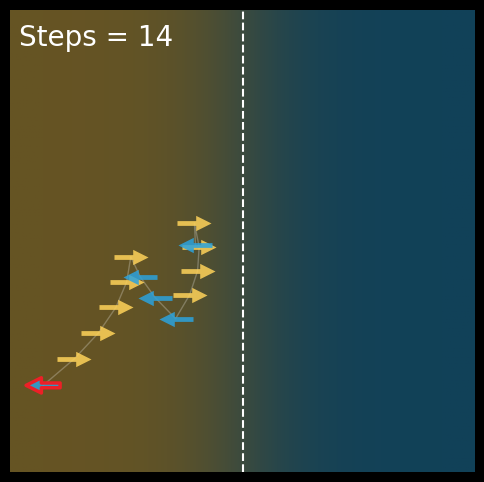

In [40]:
save_dir = HACKIN_DIR + '/sample_rollouts_1'
os.makedirs(save_dir, exist_ok=True)

  0%|                                  | 1/1024 [00:00<02:12,  7.70it/s]/var/folders/j5/ks68pdf144xgrs0s77q51qxw0000gn/T/ipykernel_15739/1293704022.py:4: UserWarning: Ignoring specified arguments in this call because figure with num: 0 already exists
  fig=plt.figure(0, (6, 6), facecolor='k')
100%|███████████████████████████████| 1024/1024 [01:38<00:00, 10.40it/s]


<Figure size 640x480 with 0 Axes>

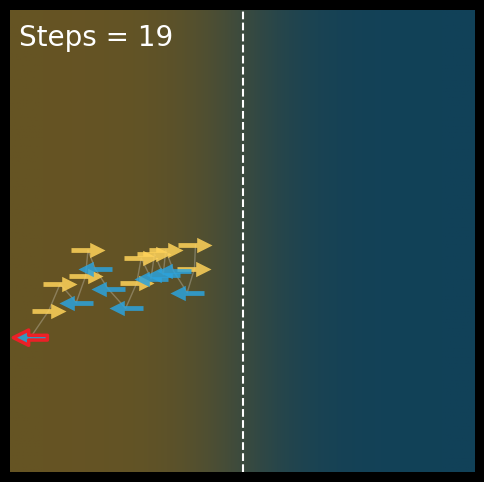

In [42]:
for k in tqdm(range(len(eps))):

    plt.clf()
    fig=plt.figure(0, (6, 6), facecolor='k')
    ax=fig.add_subplot(111, facecolor='k')
    
    ep=eps[k]
    obs_e, act_e = ep['obs'], ep['act']
    ang, angvel = np.degrees(obs_e[:, 2]), np.degrees(obs_e[:, 3])
    A, V = np.meshgrid(np.linspace(*ANG_LIM, 160), np.linspace(*VEL_LIM, 160))
    P_right_grid = 1 / (1 + np.exp(-(t1 * A + t2 * V)))
    ax.imshow(P_right_grid, origin='lower', cmap=cmap, vmin=0, vmax=1,
              extent=[*ANG_LIM, *VEL_LIM], aspect='auto', alpha=0.4)
    ax.contour(A, V, P_right_grid, levels=[0.5], colors='w', linestyles='--', linewidths=1.5)
    ax.plot(ang, angvel, color='w', lw=1.0, alpha=0.25, zorder=3, solid_capstyle='round')
    m = act_e == 1
    ax.scatter(ang[m],  angvel[m],  marker=RIGHT_ARROW, s=600, color=YELLOW, alpha=0.85, linewidths=0, zorder=4)
    ax.scatter(ang[~m], angvel[~m], marker=LEFT_ARROW,  s=600, color=BLUE,   alpha=0.85, linewidths=0, zorder=4)
    made_it = len(act_e) == 500
    ax.scatter([ang[-1]], [angvel[-1]],
               marker=(RIGHT_ARROW if act_e[-1]==1 else LEFT_ARROW), s=600,
               facecolors='none', edgecolors=('w' if made_it else RED), linewidths=2.5, zorder=5)
    ax.text(0.02, 0.97, f'Steps = {len(act_e)}', transform=ax.transAxes,
            ha='left', va='top', color='w', fontsize=20)
    ax.set_xlim(*ANG_LIM); ax.set_ylim(*VEL_LIM)
    # ax.set_xlabel('pole angle (degrees)'); ax.set_ylabel('pole angular velocity')
    # ax.set_title('State Space'); 
    style_ax(ax)
    plt.axis('off')

    fig.savefig(save_dir + '/' + str(k).zfill(4) + '.png', dpi=240, facecolor='k')